### Linear Neural Network Regression with Dive into Deeplearning

Linear Regression problem with neural network

Kaggle House Prices dataset (House Prices: Advanced Regression Techniques)

In [1]:
import pandas as pd
import numpy as np

In [2]:
train_data = pd.read_csv("data/house-prices/train.csv")
test_data = pd.read_csv("data/house-prices/test.csv")
train_data.shape, test_data.shape

((1460, 81), (1459, 80))

**Conselho:** antes de jogar `train_data` direto num modelo linear, olhe a distribuição de `SalePrice` — ela é bem assimétrica. O próprio capítulo 3 do D2L treina em `log(SalePrice)` em vez do valor bruto, porque o erro percentual importa mais que o erro absoluto em preços de imóveis (errar US$ 50k numa casa de US$ 100k é grave; na de US$ 1M, é ruído). Aplique `np.log1p` no target antes de treinar e `np.expm1` para desfazer na hora de avaliar/prever.

**Conselho de vida:** o overfitting não é só um problema de modelo — é um hábito. Otimizar demais para o feedback de um único contexto (uma prova, uma review, uma pessoa) tende a generalizar mal para a vida real. Vale a pena, de vez em quando, validar suas decisões contra um "conjunto de teste" diferente do que você usou para treinar suas crenças.

**Teste VS Code:** se você está lendo isso no VS Code sem ter recarregado nada manualmente, a sincronização em tempo real funcionou aqui também.

In [3]:
type(train_data), train_data.columns.tolist()[:10], len(train_data.columns)

(pandas.DataFrame,
 ['Id',
  'MSSubClass',
  'MSZoning',
  'LotFrontage',
  'LotArea',
  'Street',
  'Alley',
  'LotShape',
  'LandContour',
  'Utilities'],
 81)

In [4]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
train_data.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

In [6]:
missing = train_data.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [7]:
train_data["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## Pré-processamento

Seguindo o D2L §3.6: concatenamos treino e teste para garantir o mesmo encoding, normalizamos features numéricas e fazemos one-hot nas categóricas.

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# Remove Id (não é feature) e concatena treino + teste para preprocessing uniforme
n_train = train_data.shape[0]
all_features = pd.concat([train_data.drop(['Id', 'SalePrice'], axis=1),
                           test_data.drop('Id', axis=1)])

# Features numéricas: preenche NaN com média e padroniza (μ=0, σ=1)
numeric_cols = all_features.select_dtypes(include=[np.number]).columns
all_features[numeric_cols] = all_features[numeric_cols].apply(
    lambda x: (x - x.mean()) / (x.std() + 1e-8))
all_features[numeric_cols] = all_features[numeric_cols].fillna(0)

# Features categóricas: one-hot (dummy_na=True cria coluna para NaN)
all_features = pd.get_dummies(all_features, dummy_na=True)

print(f'Shape após preprocessing: {all_features.shape}')

Shape após preprocessing: (2919, 330)


In [10]:
# Converte para tensores (.astype garante que booleanos do get_dummies viram float)
train_features = torch.tensor(all_features.iloc[:n_train].values.astype(np.float32))
test_features  = torch.tensor(all_features.iloc[n_train:].values.astype(np.float32))

# Target: log1p(SalePrice) — reduz assimetria e penaliza erros percentuais
train_labels = torch.tensor(
    np.log1p(train_data['SalePrice'].values), dtype=torch.float32).reshape(-1, 1)

print(f'train_features: {train_features.shape}')
print(f'test_features:  {test_features.shape}')
print(f'train_labels:   {train_labels.shape}')

train_features: torch.Size([1460, 330])
test_features:  torch.Size([1459, 330])
train_labels:   torch.Size([1460, 1])


## Modelo e métrica

Modelo linear simples: uma camada `nn.Linear(in, 1)`.  
Métrica: **RMSLE** (Root Mean Squared Log Error) — como já treinamos em log-escala, é simplesmente o RMSE sobre as predições.

In [11]:
in_features = train_features.shape[1]

def get_net():
    return nn.Sequential(nn.Linear(in_features, 1))

loss_fn = nn.MSELoss()

def log_rmse(net, features, labels):
    """RMSE no espaço log — equivale ao RMSLE no espaço original."""
    with torch.no_grad():
        preds = net(features)
        return torch.sqrt(loss_fn(preds, labels)).item()

## Loop de treino

In [12]:
def train(net, train_feat, train_lbl, val_feat, val_lbl,
          num_epochs, lr, weight_decay, batch_size):
    train_ls, val_ls = [], []
    dataset = TensorDataset(train_feat, train_lbl)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)

    for epoch in range(num_epochs):
        net.train()
        for X, y in loader:
            optimizer.zero_grad()
            loss_fn(net(X), y).backward()
            optimizer.step()
        net.eval()
        train_ls.append(log_rmse(net, train_feat, train_lbl))
        if val_lbl is not None:
            val_ls.append(log_rmse(net, val_feat, val_lbl))

    return train_ls, val_ls

## K-Fold Cross-Validation

O D2L usa k=5. A cada fold, treina num subconjunto e valida no restante para estimar o erro de generalização sem tocar no test set.

In [13]:
def get_fold(k, i, X, y):
    fold = X.shape[0] // k
    val_X, val_y = X[i*fold:(i+1)*fold], y[i*fold:(i+1)*fold]
    tr_X = torch.cat([X[:i*fold], X[(i+1)*fold:]], dim=0)
    tr_y = torch.cat([y[:i*fold], y[(i+1)*fold:]], dim=0)
    return tr_X, tr_y, val_X, val_y

def k_fold(k, X, y, num_epochs, lr, weight_decay, batch_size):
    tr_sum, val_sum = 0, 0
    for i in range(k):
        tr_X, tr_y, val_X, val_y = get_fold(k, i, X, y)
        net = get_net()
        tr_ls, val_ls = train(net, tr_X, tr_y, val_X, val_y,
                               num_epochs, lr, weight_decay, batch_size)
        tr_sum  += tr_ls[-1]
        val_sum += val_ls[-1]
        print(f'  fold {i+1:d}  train RMSLE={tr_ls[-1]:.4f}  val RMSLE={val_ls[-1]:.4f}')
    return tr_sum / k, val_sum / k

In [14]:
k           = 5
num_epochs  = 100
lr          = 0.05
weight_decay= 1e-4
batch_size  = 64

print('K-Fold Cross-Validation (linear):')
tr_rmsle, val_rmsle = k_fold(k, train_features, train_labels,
                              num_epochs, lr, weight_decay, batch_size)
print(f'\nMédia → train RMSLE={tr_rmsle:.4f}  val RMSLE={val_rmsle:.4f}')

K-Fold Cross-Validation (linear):


  fold 1  train RMSLE=0.1791  val RMSLE=0.1958


  fold 2  train RMSLE=0.1338  val RMSLE=0.1915


  fold 3  train RMSLE=0.3075  val RMSLE=0.3397


  fold 4  train RMSLE=0.1984  val RMSLE=0.2034


  fold 5  train RMSLE=0.1978  val RMSLE=0.2576

Média → train RMSLE=0.2033  val RMSLE=0.2376


## Treino final e predição

Com os hiperparâmetros validados, treina no dataset completo e gera `submission.csv`.

In [15]:
def train_and_predict(tr_feat, tr_lbl, te_feat,
                      num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    tr_ls, _ = train(net, tr_feat, tr_lbl, None, None,
                     num_epochs, lr, weight_decay, batch_size)
    print(f'train RMSLE final: {tr_ls[-1]:.4f}')

    net.eval()
    with torch.no_grad():
        preds = np.expm1(net(te_feat).numpy())  # desfaz log1p

    submission = pd.DataFrame({'Id': test_data['Id'], 'SalePrice': preds.flatten()})
    submission.to_csv('data/house-prices/submission.csv', index=False)
    print('submission.csv salvo.')
    return net, submission

net_final, submission = train_and_predict(
    train_features, train_labels, test_features,
    num_epochs, lr, weight_decay, batch_size)

submission.head()

train RMSLE final: 0.2114
submission.csv salvo.


,Id,SalePrice
0,1461,132561.093750
1,1462,36459.523438
2,1463,181801.593750
3,1464,194857.312500
4,1465,222766.890625


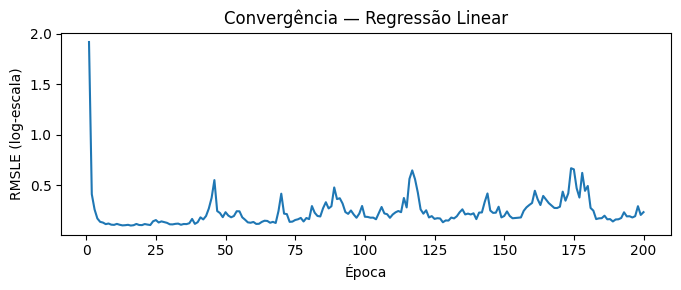

In [16]:
# Curva de treino para visualizar convergência
net_debug = get_net()
tr_ls, _ = train(net_debug, train_features, train_labels, None, None,
                 200, lr, weight_decay, batch_size)

plt.figure(figsize=(7, 3))
plt.plot(range(1, 201), tr_ls)
plt.xlabel('Época'); plt.ylabel('RMSLE (log-escala)')
plt.title('Convergência — Regressão Linear')
plt.tight_layout()
plt.show()